# RNN

In [1]:
from collections import Counter
import numpy as np

seq = "abcdefghijklmnopqrstuvwxyz abcdefghijklmnopqrstuvwxyz abcdefghijklmnopqrstuvwxyz"
seq = "Träningsformen grundades av tävlingscyklisten Johnny Goldberg 1989. Han hade förlorat loppet Race Across America (RAAM) 1987 och sökte en träningsform som gjorde att han kunde träna utan att lämna hemmet. Han byggde om sin egen motionscykel för att den mer skulle likna en riktig racercykel och började så småningom hålla spinningklasser i sitt garage. Han kom senare att utveckla spinningcyklar för massproduktion i takt med att träningsformen växte."

c = Counter(seq)

cl = list(c.keys())

vocab = {}
inv_vocab = {}

for i, k in enumerate(cl):
    vocab[k] = i
    inv_vocab[i] = k

vocab_size = len(vocab)

lookup = np.eye(vocab_size)

seq_encoded = []
for ch in seq:
    seq_encoded.append(lookup[vocab[ch]])

arr = np.array(seq_encoded)

x = np.expand_dims(np.array(seq_encoded[:-1]), axis=0)
y = np.expand_dims(np.array(seq_encoded[1:]), axis=0)

print(f"Unique tokens: {vocab_size}")
print(f"Total tokens: {len(seq_encoded)}")


Unique tokens: 41
Total tokens: 451


In [2]:
from NNLibrary.network import Network
from NNLibrary.Layers.learnable import RNN, LSTM
from NNLibrary.Layers.activations import Sigmoid, Softmax

network = Network(
    layers=[
        LSTM(in_dim=vocab_size, hidden_dim=64, out_dim=vocab_size),
        # Sigmoid(),
        # Softmax(),
    ]
)

n_params = network.count_parameters()
print(f"Total parameter count: {n_params}")

Total parameter count: 29801


In [3]:
from NNLibrary.Layers.activations import Softmax

def sample_text(network, length=64, T=1, np_seed=None):
    np.random.seed(np_seed)
    softmax = Softmax(T=T)

    seed = " "  
    context = [lookup[vocab[ch]] for ch in seed] # List of one-hot

    out_seq = seed
    out_len = length

    for _ in range(out_len):
        x_in = np.expand_dims(np.array(context), axis=0)
        logits = network.forward(x_in)
        pred = softmax.forward(logits)

        next_id = np.random.choice(vocab_size, p=pred[0, -1])
        next_ch = inv_vocab[next_id]

        out_seq += next_ch
        context.append(lookup[next_id])

    print(out_seq)
    return out_seq

Epoch 0
Loss: 3.7080770051154115
 9ä kdbgMjjxHn8Jåa79mufoo97oJThåra)yf8uMjrödp1chn7pT98l1y9aJränMA
Epoch 100
Loss: 2.7328130296568656
 ohn att tannn g ltttt nnnn  lttte annn  ttttttnnngg loe   at  tt
Epoch 200
Loss: 2.1178084360602356
 kt tten see  attnnng kllliininnnggkllsse  atttt nnnggykllo  ännn
Epoch 300
Loss: 2.004538496675513
 lattt en att ttnnnggkllee  tttnnnggse ommn innggckllsspppinningg
Epoch 400
Loss: 1.453134741268616
 börde sttt ännggsee st ännnggee om ininggckllasppninn ykller sr 
Epoch 500
Loss: 1.1099486453144511
 han skten attt unngge aom innngggkll sppinniningaarser för aasst
Epoch 600
Loss: 0.8810729554448685
 han sonngeroriningcykllsse  sktte at ttt ukan set at tinnggseree
Epoch 700
Loss: 0.7042566562210637
 han spinggkllessinnin ykerer sör sttt tinn guraee era at engge o
Epoch 800
Loss: 0.712041262430668
 han föra stttt uunade tttäningsfåme mmninggcykll opin iningfrmm 
Epoch 900
Loss: 0.4151001674836805
 han föra stttringcykel spin gacyde så måmin uhan att mänan s

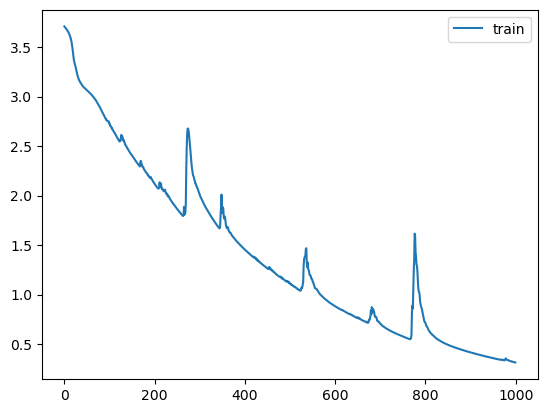

In [4]:
import matplotlib.pyplot as plt
from NNLibrary.Layers.loss import CrossEntropy, SoftmaxCE
from NNLibrary.optimizers import Adam, GradientDescent

epochs = 1000
lr = 0.001

loss_fn = SoftmaxCE()
optimizer = Adam(lr, beta=0.9, gamma=0.999)
# optimizr = GradientDescent(lr=lr)

metrics = {"train": {"loss": [], "epoch": []}, "val": {"loss": [], "epoch": []}, "epochs": []}

for epoch in range(epochs):
    network.train()

    metrics["epochs"].append(epoch)

    out = network.forward(x)
    loss = loss_fn.forward(out, y)

    network.backprop(loss_fn, optimizer) # Backpropagation and weight updates
    
    metrics["train"]["loss"].append(loss)
    metrics["train"]["epoch"].append(epoch)

    if epoch % 100 == 0:
        print(f"Epoch {epoch}")
        print(f"Loss: {loss}")
        out_seq = sample_text(network, T=0.1)


plt.plot(metrics["train"]["epoch"], metrics["train"]["loss"], label="train")
plt.legend()
plt.show()

In [10]:

out_seq = sample_text(network, T=0.1)

 han föra sttring cklier en sittiggga loss enin han förrlarar sör
